In [287]:
import pandas as pd
import numpy as np
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import time 

In [288]:
#reading the  data
reviews_df = pd.read_csv('data/reviews.csv')
listings_df = pd.read_csv('data/listings.csv')

In [289]:
# method to fill NaN values with the mean of the column
def fill_na_with_mean(df, column):
    if column in df.columns:
        mean_value = df[column].mean()
        df[column].fillna(mean_value, inplace=True)
    else:
        raise ValueError(f"Column {column} does not exist in the DataFrame.")

In [290]:
def clean_listings_df():
    # remove columns with too many missing values or unnecessary information
    listings_df.drop(columns=[
        'neighborhood_overview', 'host_about', 'host_location',
        'host_response_time', 'host_response_rate', 'host_acceptance_rate',
        'host_is_superhost', 'host_neighbourhood', 'host_verifications',
        'host_thumbnail_url', 'license', 'calendar_updated',
        'calendar_last_scraped', 'last_review', 'first_review', 'neighbourhood_group_cleansed',
        'last_scraped', 'source', 'neighbourhood', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
        'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    ], inplace=True)
    # remove rows with missing values in important columns
    listings_df.dropna(subset=['price', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'has_availability'], inplace=True)
    listings_df['description'].fillna('no description', inplace=True)

    # fill NaN values in review score columns with the mean of the column
    for col in ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
                'review_scores_checkin', 'review_scores_communication',
                'review_scores_location', 'review_scores_value', 'reviews_per_month']:
        # fill NaN values with the mean of the column
        fill_na_with_mean(listings_df, col)


    # turn price column into float, removing dollar sign
    listings_df['price'] = listings_df['price'].str.replace('[$,]', '', regex=True).astype(float)
    # change id column name to listing_id for consistency with reviews_df
    listings_df.rename(columns={'id': 'listing_id'}, inplace=True)
    
    
    return listings_df

In [291]:
def clean_reviews_df():
    # remove columns with too many missing values or unnecessary information
    # TODO: Add columns to drop if necessary. I think if we use this for sentiment analysis, we dont need a lot of the columns.
    reviews_df.drop(columns=['date', 'reviewer_id', 'reviewer_name'], inplace=True)

    # remove rows with missing values in important columns, in this case no comments
    reviews_df.dropna(subset=['comments'], inplace=True)
    return reviews_df

In [292]:
def join_dfs(*dfs, join_key='listing_id', how='left'):
    if not dfs:
        raise ValueError("At least one DataFrame must be provided.")

    # Ensure join_key is set as index for optimization (optional)
    merged_df = dfs[0]
    for df in dfs[1:]:
        merged_df = pd.merge(merged_df, df, on=join_key, how=how, copy=False, sort=False)
    return merged_df

In [293]:
def export_processed_data(arg):
    if len(arg) == 0:
        raise ValueError("At least one DataFrame must be provided.")
    arg.to_csv('./processed-data/clean-data.csv', index=False)

In [294]:
nDf = join_dfs(clean_listings_df(), clean_reviews_df())
print(nDf.head())
print("finished dataframe shape ", nDf.shape)

# export_processed_data(nDf)
# TODO: the finished csv file looks kinda weird. get rid of the <br> and such?

C:\Users\fabia\AppData\Local\Temp\ipykernel_29024\1752424774.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listings_df['description'].fillna('no description', inplace=True)
C:\Users\fabia\AppData\Local\Temp\ipykernel_29024\3691534955.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

   listing_id                        listing_url       scrape_id  \
0        3781  https://www.airbnb.com/rooms/3781  20250315060211   
1        3781  https://www.airbnb.com/rooms/3781  20250315060211   
2        3781  https://www.airbnb.com/rooms/3781  20250315060211   
3        3781  https://www.airbnb.com/rooms/3781  20250315060211   
4        3781  https://www.airbnb.com/rooms/3781  20250315060211   

                        name  \
0  HARBORSIDE-Walk to subway   
1  HARBORSIDE-Walk to subway   
2  HARBORSIDE-Walk to subway   
3  HARBORSIDE-Walk to subway   
4  HARBORSIDE-Walk to subway   

                                         description  \
0  Fully separate apartment in a two apartment bu...   
1  Fully separate apartment in a two apartment bu...   
2  Fully separate apartment in a two apartment bu...   
3  Fully separate apartment in a two apartment bu...   
4  Fully separate apartment in a two apartment bu...   

                                         picture_url  host_id

In [295]:
#nDf.dtypes

In [296]:
# some feature engeneering 
#nDf['neighbourhood_cleansed'].unique()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# nDf['neighbourhood_cleansed_encoded'] = le.fit_transform(nDf['neighbourhood_cleansed'])  # IMPORTANT CHATGPT SAYS THIS MAY BE PROBLEMATIC FOR LINEAR REG !!!
# nDf['neighbourhood_cleansed_encoded'].dtype
nDf = pd.get_dummies(nDf, columns=['neighbourhood_cleansed'], prefix='neigh')
nDf = nDf.astype({col: 'Int64' for col in nDf.columns if nDf[col].dtype == 'bool'})


In [297]:
nDf.dtypes

listing_id                        int64
listing_url                      object
scrape_id                         int64
name                             object
description                      object
                                  ...  
neigh_South Boston                Int64
neigh_South Boston Waterfront     Int64
neigh_South End                   Int64
neigh_West End                    Int64
neigh_West Roxbury                Int64
Length: 82, dtype: object

In [298]:
#dropping all id coloumns (just for testing)
nDf = nDf.loc[:, ~nDf.columns.str.contains('id', case=False)]
todo_df = nDf.select_dtypes(include=['int', 'float64'])

In [299]:

columns_to_drop = ["minimum_minimum_nights" , "maximum_minimum_nights" , "minimum_maximum_nights" , "maximum_maximum_nights"] #, "estimated_revenue_l365d" ]
todo_df = todo_df.drop(columns=columns_to_drop)
todo_df = todo_df.drop_duplicates()
todo_df.dtypes


host_listings_count              float64
host_total_listings_count        float64
latitude                         float64
longitude                        float64
accommodates                       int64
bathrooms                        float64
bedrooms                         float64
beds                             float64
price                            float64
minimum_nights                     int64
maximum_nights                     int64
minimum_nights_avg_ntm           float64
maximum_nights_avg_ntm           float64
availability_30                    int64
availability_60                    int64
availability_90                    int64
availability_365                   int64
number_of_reviews                  int64
number_of_reviews_ltm              int64
number_of_reviews_l30d             int64
availability_eoy                   int64
number_of_reviews_ly               int64
estimated_occupancy_l365d          int64
estimated_revenue_l365d          float64
review_scores_ra

In [300]:
correlations = todo_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlations)

price                            1.000000
accommodates                     0.519946
bathrooms                        0.483732
beds                             0.480714
bedrooms                         0.398584
estimated_revenue_l365d          0.348026
latitude                         0.152106
neigh_Bay Village                0.146280
host_total_listings_count        0.129016
neigh_Downtown                   0.114285
review_scores_location           0.111490
longitude                        0.106249
host_listings_count              0.096063
review_scores_cleanliness        0.091751
neigh_Back Bay                   0.085129
availability_30                  0.083563
availability_365                 0.083264
neigh_South End                  0.079544
neigh_Longwood Medical Area      0.076787
availability_eoy                 0.075682
review_scores_rating             0.074673
neigh_Charlestown                0.067607
neigh_Chinatown                  0.064649
availability_60                  0

In [301]:
features = todo_df.drop(columns=['price'])  
targets = todo_df['price']


In [302]:

# features = features.drop(columns=[
#     'estimated_occupancy_l365d',
#     'reviews_per_month',
#     'number_of_reviews',
#     'number_of_reviews_ltm',
#     'number_of_reviews_l30d',
#     'number_of_reviews_ly',
#     'availability_eoy',
#     'availability_365'
# ])



In [303]:
features.dtypes

host_listings_count              float64
host_total_listings_count        float64
latitude                         float64
longitude                        float64
accommodates                       int64
bathrooms                        float64
bedrooms                         float64
beds                             float64
minimum_nights                     int64
maximum_nights                     int64
minimum_nights_avg_ntm           float64
maximum_nights_avg_ntm           float64
availability_30                    int64
availability_60                    int64
availability_90                    int64
availability_365                   int64
number_of_reviews                  int64
number_of_reviews_ltm              int64
number_of_reviews_l30d             int64
availability_eoy                   int64
number_of_reviews_ly               int64
estimated_occupancy_l365d          int64
estimated_revenue_l365d          float64
review_scores_rating             float64
review_scores_ac

In [304]:
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=1)               

In [305]:
# random forest model
print("Training model...")

estimators_list = [200] ## no big diffrence
mse_scores = []

for n in estimators_list:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"n_estimators = {n} --> MSE: {mse:.2f}")

Training model...
n_estimators = 200 --> MSE: 5429.75


In [306]:
features = features.reset_index(drop=True)
features.loc[50]


host_listings_count                  1.0
host_total_listings_count            1.0
latitude                          42.346
longitude                       -71.1399
accommodates                         4.0
bathrooms                            1.0
bedrooms                             2.0
beds                                 1.0
minimum_nights                       4.0
maximum_nights                    1125.0
minimum_nights_avg_ntm               4.0
maximum_nights_avg_ntm            1125.0
availability_30                     14.0
availability_60                     32.0
availability_90                     54.0
availability_365                    54.0
number_of_reviews                  323.0
number_of_reviews_ltm                2.0
number_of_reviews_l30d               2.0
availability_eoy                    54.0
number_of_reviews_ly                 0.0
estimated_occupancy_l365d           16.0
estimated_revenue_l365d           2128.0
review_scores_rating                4.71
review_scores_ac

In [307]:
features = features.drop_duplicates()

In [308]:
features

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,...,neigh_Mattapan,neigh_Mission Hill,neigh_North End,neigh_Roslindale,neigh_Roxbury,neigh_South Boston,neigh_South Boston Waterfront,neigh_South End,neigh_West End,neigh_West Roxbury
0,2.0,6.0,42.364130,-71.029910,2,1.0,1.0,1.0,29,1125,...,0,0,0,0,0,0,0,0,0,0
1,12.0,15.0,42.328440,-71.095810,2,1.0,1.0,1.0,3,90,...,0,0,0,0,1,0,0,0,0,0
2,12.0,15.0,42.328020,-71.093870,4,1.0,0.0,2.0,3,730,...,0,0,0,0,1,0,0,0,0,0
3,21.0,29.0,42.351730,-71.086850,3,1.0,0.0,1.0,91,1125,...,0,0,0,0,0,0,0,0,0,0
4,21.0,29.0,42.350610,-71.087870,2,1.0,0.0,1.0,32,1125,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3616,22.0,68.0,42.367523,-71.052688,6,1.5,3.0,3.0,5,365,...,0,0,1,0,0,0,0,0,0,0
3617,14.0,23.0,42.357720,-71.071090,6,2.0,2.0,3.0,1,365,...,0,0,0,0,0,0,0,0,0,0
3618,30.0,71.0,42.318576,-71.106661,8,1.0,3.0,3.0,1,365,...,0,0,0,0,0,0,0,0,0,0
3619,22.0,68.0,42.360268,-71.069963,7,2.0,4.0,5.0,5,365,...,0,0,0,0,0,0,0,0,0,0


In [309]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Show a few rows
print(comparison_df.head(20))

    Actual  Predicted
0    179.0    183.040
1    165.0    220.605
2    110.0    152.390
3    239.0    236.885
4    205.0    217.190
5     56.0     73.765
6    251.0    231.275
7    188.0    264.300
8    288.0    264.630
9    248.0    234.305
10    58.0     53.205
11   134.0    209.520
12   270.0    363.520
13   227.0    240.610
14   155.0    166.285
15   144.0    158.375
16   124.0    134.205
17   183.0    171.720
18   299.0    233.770
19   115.0    123.870


In [310]:
print(comparison_df[comparison_df['Actual'] != comparison_df['Predicted']].head(-20))

     Actual  Predicted
0     179.0    183.040
1     165.0    220.605
2     110.0    152.390
3     239.0    236.885
4     205.0    217.190
..      ...        ...
700   333.0    269.770
701   129.0    268.265
702   630.0    276.425
703    55.0     65.815
704   214.0    212.560

[705 rows x 2 columns]


In [311]:
import shap

# Create a SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_train.sample(100))

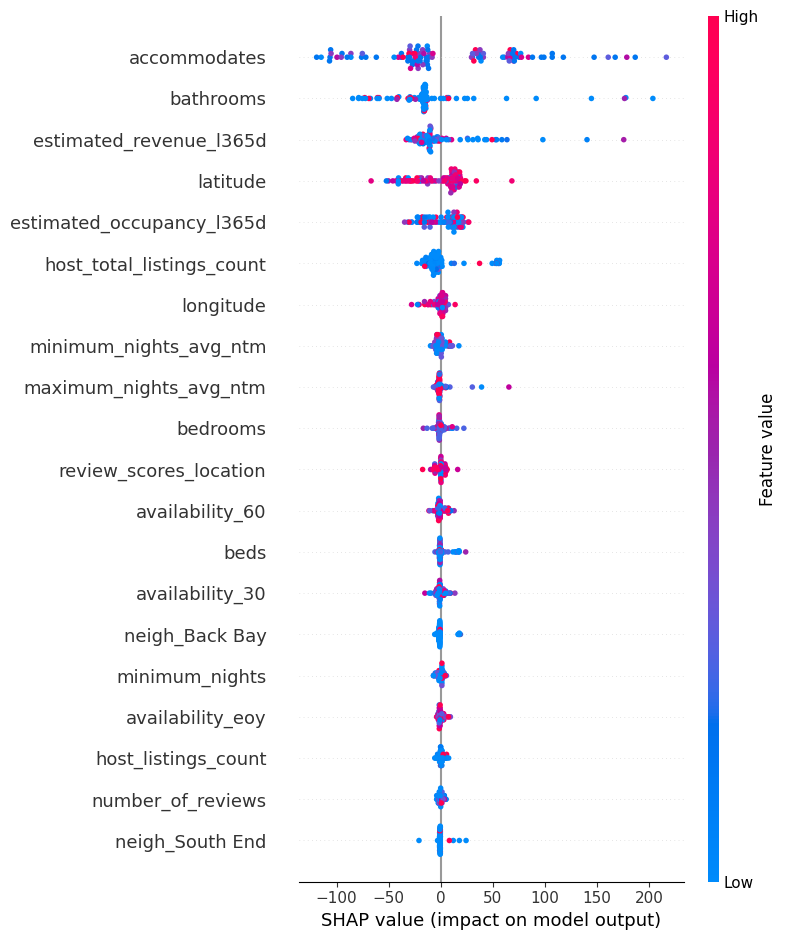

In [312]:
shap.summary_plot(shap_values, X_test.sample(100))